# Web Scraping Books Data Using Python

## CodeAlpha Data Analytics Internship

### Objective
To collect book information from a website using web scraping techniques and perform basic exploratory analysis on the collected dataset.

# Research Questions

1. What is the distribution of book ratings?
2. What is the price distribution of books?
3. Which rating category appears most frequently?
4. Are most books available in stock?

In [2]:
# Import required libraries

import requests
from bs4 import BeautifulSoup
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Website URL

url = "https://books.toscrape.com/"

# Send HTTP request

response = requests.get(url)

print("Status Code:", response.status_code)

Status Code: 200


In [4]:
# Parse webpage content

soup = BeautifulSoup(
    response.text,
    "html.parser"
)

print("HTML Parsed Successfully")

HTML Parsed Successfully


In [5]:
book = soup.find("article")

book

<article class="product_pod">
<div class="image_container">
<a href="catalogue/a-light-in-the-attic_1000/index.html"><img alt="A Light in the Attic" class="thumbnail" src="media/cache/2c/da/2cdad67c44b002e7ead0cc35693c0e8b.jpg"/></a>
</div>
<p class="star-rating Three">
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
<i class="icon-star"></i>
</p>
<h3><a href="catalogue/a-light-in-the-attic_1000/index.html" title="A Light in the Attic">A Light in the ...</a></h3>
<div class="product_price">
<p class="price_color">Â£51.77</p>
<p class="instock availability">
<i class="icon-ok"></i>
    
        In stock
    
</p>
<form>
<button class="btn btn-primary btn-block" data-loading-text="Adding..." type="submit">Add to basket</button>
</form>
</div>
</article>

In [6]:
# Create empty lists

titles = []
prices = []
ratings = []
availability = []

In [7]:
# Find all books

books = soup.find_all("article")

for book in books:

    title = book.h3.a["title"]

    price = book.find(
        "p",
        class_="price_color"
    ).text

    rating = book.find(
        "p",
        class_="star-rating"
    )["class"][1]

    stock = book.find(
        "p",
        class_="instock availability"
    ).text.strip()

    titles.append(title)
    prices.append(price)
    ratings.append(rating)
    availability.append(stock)

In [8]:
df = pd.DataFrame({
    "Title": titles,
    "Price": prices,
    "Rating": ratings,
    "Availability": availability
})

df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,Â£51.77,Three,In stock
1,Tipping the Velvet,Â£53.74,One,In stock
2,Soumission,Â£50.10,One,In stock
3,Sharp Objects,Â£47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,Â£54.23,Five,In stock


In [9]:
df.to_csv(
    "books_data.csv",
    index=False
)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Title         20 non-null     object
 1   Price         20 non-null     object
 2   Rating        20 non-null     object
 3   Availability  20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes


In [16]:
# Remove non-numeric characters

df["Price"] = (
    df["Price"]
    .str.replace("Â", "", regex=False)
    .str.replace("£", "", regex=False)
    .astype(float)
)

df.head()

,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,Three,In stock
1,Tipping the Velvet,53.74,One,In stock
2,Soumission,50.10,One,In stock
3,Sharp Objects,47.82,Four,In stock
4,Sapiens: A Brief History of Humankind,54.23,Five,In stock


In [17]:
df["Rating"].value_counts()

Rating
One      6
Four     4
Five     4
Three    3
Two      3
Name: count, dtype: int64

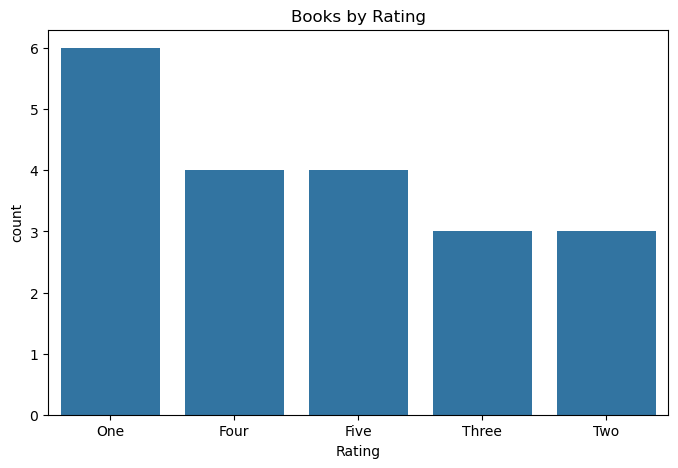

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Rating",
    order=df["Rating"]
    .value_counts()
    .index
)

plt.title("Books by Rating")

plt.savefig("books_by_rating.png")

plt.show()

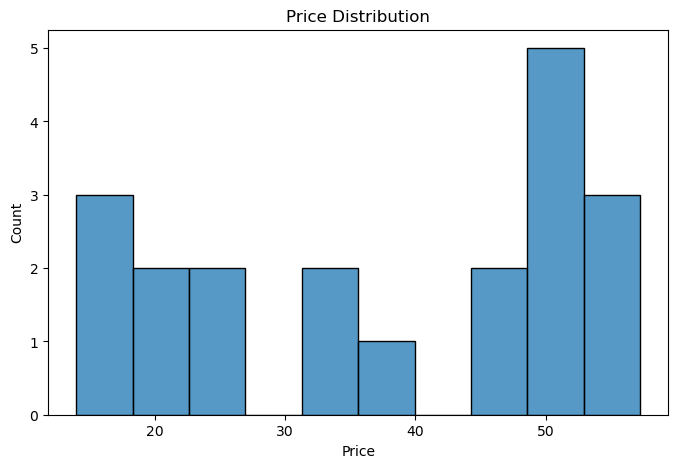

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Price"],
    bins=10
)

plt.title("Price Distribution")

plt.savefig("price_distribution.png")

plt.show()

# Key Insights

1. Successfully extracted book data from a live website.
2. Created a structured dataset using Python.
3. Most books fall within a moderate price range.
4. Ratings distribution provides insights into book quality.
5. Web scraping can be used to automate data collection.

# Conclusion

This project demonstrated the use of Python, Requests, BeautifulSoup, and Pandas for web scraping and data analysis.

The scraped data was transformed into a structured dataset and analyzed using visualizations, showcasing how web data can be collected and converted into actionable insights.